In [ ]:
import numpy as np
from utils.dataset_sampling import read_dataset

In [ ]:
# get avg word count of context per paragraph and in total
from analysis.utils import read_trees_to_df
model = 'google/gemma-3-1b-it'
dataset = 'POPQA'
pop_df = read_trees_to_df("paraphrase", model, dataset)

model = 'google/gemma-3-1b-it'
dataset = 'TQA'
tqa_df = read_trees_to_df("paraphrase", model, dataset)

tqa_raw = read_dataset("TQA", 1000)
tqa_df['cluster_id'] = tqa_raw['cluster_id']
pop_raw = read_dataset("POPQA", 1000)
print(pop_raw.columns)
pop_df['prop'] = pop_raw['prop']

pop_df_len_sampled =bucket_and_upsample(pop_df)
pop_df_len_sampled =bucket_and_upsample(pop_df)

Index(['gen_modelId', 'question_id', 'layer', 'id', 'type', 'para_type',
       'prompt', 'rag_closest_match', 'rag_entities', 'possible_answers',
       'metadata', 'wiki_title', 'rag_found_match', 'base_found_match',
       'base_f1_1', 'base_f1_L', 'rag_f1_1', 'rag_f1_L', 'base_rec_1',
       'base_rec_L', 'rag_rec_1', 'rag_rec_L', 'base_prec_1', 'base_prec_L',
       'rag_prec_1', 'rag_prec_L', 'root_similarity_score', 'complexity_score',
       'fk_score', 'dc_score', 'similarity', 'base', 'base_rag'],
      dtype='object')


In [ ]:
from utils.dataset_sampling import read_dataset
tqa_raw = read_dataset("TQA", 1000)
tqa_df['cluster_id'] = tqa_raw['cluster_id']
pop_raw = read_dataset("POPQA", 1000)
print(pop_raw.columns)
pop_df['prop'] = pop_raw['prop']

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def plot_len(df):
    pop_df = df.copy()
    # Extract contexts and join them
    pop_df['rag_context'] = pop_df['rag_closest_match'].apply(
        lambda tup_list: [c[0]["context"] for c in tup_list]
    )
    pop_df['rag_context_joined'] = pop_df['rag_context'].apply(
        lambda context_list: " ".join(context_list)
    )

    # Compute word‐counts by row
    pop_df['joined_word_count'] = (
        pop_df['rag_context_joined']
        .dropna()             # in case some rows are NaN
        .str.split()          # split each string into a list of words
        .str.len()            # count words in each list
    )

    # Compute aggregate stats
    join_avg_word_count = pop_df['joined_word_count'].mean()
    join_std_word_count = pop_df['joined_word_count'].std()

    print(f"Mean word count per document: {join_avg_word_count:.2f}")
    print(f"Std dev of word count per document: {join_std_word_count:.2f}")

    all_docs = [
        doc 
        for doc_list in pop_df['rag_context'].dropna() 
        for doc in doc_list
    ]
    doc_word_counts = [len(doc.split()) for doc in all_docs]
    mean_word_count = np.mean(doc_word_counts)
    std_word_count  = np.std(doc_word_counts, ddof=0)
    print(f"Mean word count per document: {mean_word_count:.2f}")
    print(f"std of word count per document: {std_word_count:.2f}")

    counts, bin_edges = np.histogram(doc_word_counts, bins=6)

    # 2. Build human-readable labels
    bin_labels = [
        f"{int(bin_edges[i])}–{int(bin_edges[i+1])}" 
        for i in range(len(bin_edges)-1)
    ]

    # 3. Plot as a bar chart
    plt.figure()
    plt.bar(bin_labels, counts)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Word-count range')
    plt.ylabel('Frequency')
    plt.title('Distribution of Document Word Counts (6 Buckets)')
    plt.tight_layout()
    plt.show()


Mean word count per document: 1951.39
Std dev of word count per document: 598.93
Word-count range  |  Frequency
------------------|-----------
22–480           | 452
480–939          | 698
939–1398         | 876
1398–1856        | 2853
1856–2315        | 4661
2315–2774        | 4336


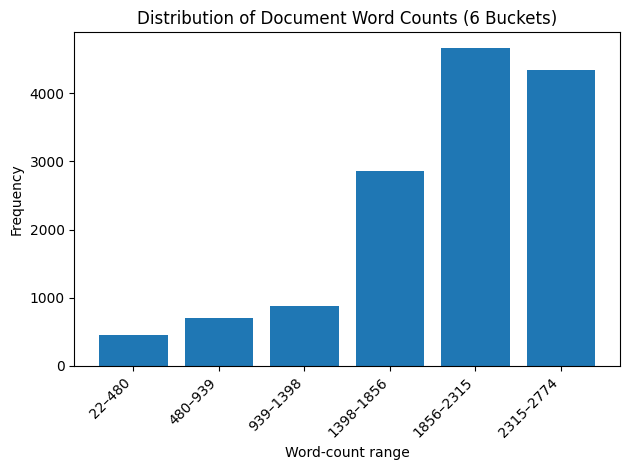

Mean word count per document: 541.33
std of word count per document: 194.13
Word-count range  |  Frequency
------------------|-----------
2–126            | 2927
126–251          | 4119
251–375          | 3726
375–500          | 2971
500–624          | 7311
624–749          | 28966


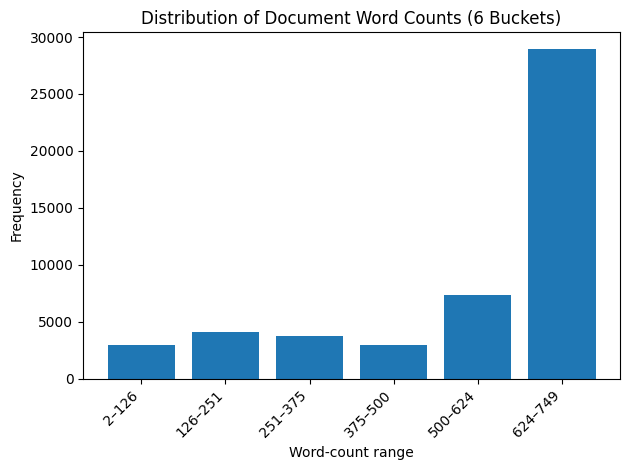

Mean word count per document: 2126.14
Std dev of word count per document: 639.53
Word-count range  |  Frequency
------------------|-----------
89–541           | 301
541–994          | 1573
994–1446         | 923
1446–1899        | 1274
1899–2351        | 4602
2351–2804        | 9099


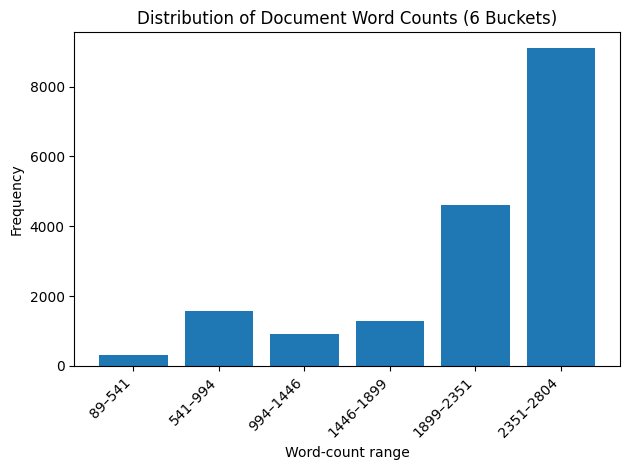

Mean word count per document: 608.40
std of word count per document: 129.35
Word-count range  |  Frequency
------------------|-----------
30–152           | 1809
152–274          | 1459
274–397          | 1826
397–519          | 2084
519–641          | 19643
641–764          | 35286


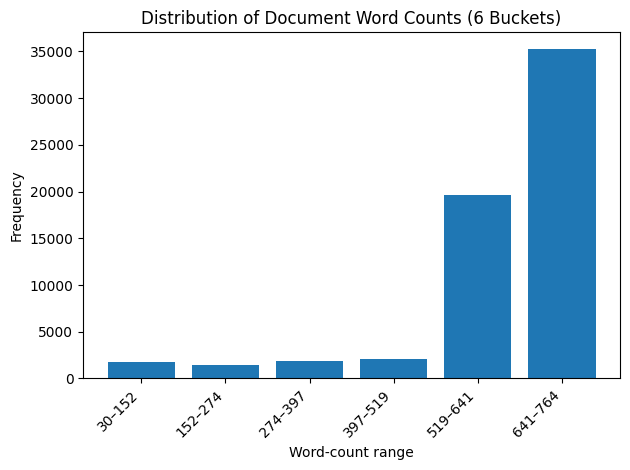

In [ ]:
pop_df_len_sampled =bucket_and_upsample(pop_df)
pop_df_len_sampled =bucket_and_upsample(pop_df)

In [ ]:
! pip install gdown
! gdown https://drive.google.com/uc?id=12kNONo0jgktxU0vWtV3Z2ZrCrB3DJPVj


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from transformers import pipeline

# 1. Load the text-classification pipeline with a QNLI-fine-tuned BERT
qnli = pipeline("text-classification", model="textattack/bert-base-uncased-QNLI") # for answer extraction
mnli = pipeline("text-classification", model="textattack/roberta-base-MNLI") # for answer verification
roberta_docnli = download from here? https://drive.google.com/file/d/12kNONo0jgktxU0vWtV3Z2ZrCrB3DJPVj/view?usp=sharing it is a .pt file
mixture = pipeline("text2text-generation", model="google/t5_xxl_true_nli_mixture")

In [ ]:
from transformers import pipeline
import spacy

# Load QNLI model and sentence tokenizer
pipe = pipeline("text-classification", model="textattack/bert-base-uncased-QNLI", batch_size=256)
nlp = spacy.load("en_core_web_sm")

def extract_sentences(text):
    """Split long text into individual sentences using spaCy."""
    sentences = []
    for seg in text.split('\n'):
        doc = nlp(seg)
        sentences.extend([sent.text.strip() for sent in doc.sents if sent.text.strip()])
    return sentences

def format_qnli_examples(question, context_text):
    """Format QNLI examples with 'text' and 'text_pair' keys."""
    sentences = extract_sentences(context_text)
    return [{"text": question, "text_pair": sent} for sent in sentences], sentences

# Example usage for a single question-context pair
question = "What is the capital of Centre?"
context = "The capital of Centre is Ouagadougou.\nJesus is reborn before Easter in 1988."

# 1. Format examples
formatted_examples, original_sentences = format_qnli_examples(question, context)

# 2. Run inference
results = pipe(formatted_examples)

# 3. Interpret
for i, res in enumerate(results):
    print(f"Sentence {i+1}:")
    print(f"  Premise    = {formatted_examples[i]['text']!r}")
    print(f"  Hypothesis = {formatted_examples[i]['text_pair']!r}")
    print(f"  → Label: {res['label']}  (score = {res['score']:.3f})\n")


In [ ]:
# compare answer with reference answer
def compare_answer(model_response, references):
    # select question modification template
    for references in list eval on MNLI model 
    


In [ ]:
# is answer entailment from passage
# longformer model vs roBERTa model
def is_entailment(model_response, passages):
    # parse topk to contain only context
    # get entailment information from model
     

In [ ]:
# https://arxiv.org/pdf/2204.07447
# from Stretching Sentence-pair NLI Models to Reason over Long Documents and Clusters (zero-shot)
def retrieve_and_classify()
    

In [ ]:
def just_longformer():
    # use longformer model to classify
    # parse topk to contain only context
    # get entailment information from model
    pass

justify no fintune / no training:
- trained /tested data
- no significant drop in performance
- self containess of facts to 1 - 2 document (Trivia + POP)